**Table of contents**<a id='toc0_'></a>    
- [1. INSTALL XGBOOST AND IMPORT LIBRARIES](#toc1_)    
- [2. LOAD AND VIEW DATA](#toc2_)    
- [3. PRE-PROCESSING STEPS](#toc3_)    
  - [3.1 FILL MISSING VALUES](#toc3_1_)    
  - [3.2 CONVERT STRING TO INT](#toc3_2_)    
- [4. EXPLORATORY DATA ANALYSIS](#toc4_)    
- [5. MODELING](#toc5_)    
  - [5.1 TRAIN - TEST SPLIT](#toc5_1_)    
  - [5.2 SCALING](#toc5_2_)    
- [6. MODELS](#toc6_)    
  - [6.1 LINEAR REGRESSION](#toc6_1_)    
  - [6.2 RANDOM FOREST](#toc6_2_)    
  - [6.3 XGBOOST](#toc6_3_)    
    - [6.3.1 XGBOOST LEARNING CURVE](#toc6_3_1_)    
    - [6.3.2 XGBOOST MODEL](#toc6_3_2_)    
- [7. FEATURE IMPORTANCE GRAPHS](#toc7_)    
- [8. MODEL COMPARISON GRAPH](#toc8_)    
- [9. K-FOLD CROSS VALIDATION](#toc9_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[1. INSTALL XGBOOST AND IMPORT LIBRARIES](#toc0_)

In [73]:
pip install xgboost


[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [74]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor



# <a id='toc2_'></a>[2. LOAD AND VIEW DATA](#toc0_)

In [75]:
# Load the dataset
df = pd.read_csv('/Users/dhruvipanchasara/Documents/ds-studio-ii/flu-ili-byregion-fluseason.csv')

In [76]:
# Display the first few rows of the dataset
df.head()

,season,date_code,weekending,region,Total_ILI,Total_Patients_Seen,Percent_ILI,Number_Providers_Reporting
0,2001-2002,200140,10/6/2001,Bay Area,3,135,2.22,2
1,2001-2002,200140,10/6/2001,California,25,1211,2.06,14
2,2001-2002,200140,10/6/2001,Central,0,0,NaN,0
3,2001-2002,200140,10/6/2001,Lower Southern,2,336,0.60,4
4,2001-2002,200140,10/6/2001,Northern,20,529,3.78,4


In [77]:
df.shape

(5946, 8)

In [78]:
df.isnull().sum()

season                         0
date_code                      0
weekending                     0
region                         0
Total_ILI                      0
Total_Patients_Seen            0
Percent_ILI                   29
Number_Providers_Reporting     0
dtype: int64

# <a id='toc3_'></a>[3. PRE-PROCESSING STEPS](#toc0_)

## <a id='toc3_1_'></a>[3.1 FILL MISSING VALUES](#toc0_)

In [79]:
# 1. Fill missing values in 'Percent_ILI' with 0, assuming that missing values indicate no cases of influenza-like illness reported
df['Percent_ILI'] = df['Percent_ILI'].fillna(0)
df

,season,date_code,weekending,region,Total_ILI,Total_Patients_Seen,Percent_ILI,Number_Providers_Reporting
0,2001-2002,200140,10/6/2001,Bay Area,3,135,2.22,2
1,2001-2002,200140,10/6/2001,California,25,1211,2.06,14
2,2001-2002,200140,10/6/2001,Central,0,0,0.00,0
3,2001-2002,200140,10/6/2001,Lower Southern,2,336,0.60,4
4,2001-2002,200140,10/6/2001,Northern,20,529,3.78,4
...,...,...,...,...,...,...,...,...
5941,2019-2020,202039,9/26/2020,California,448,50902,0.88,87
5942,2019-2020,202039,9/26/2020,Central,0,447,0.00,3
5943,2019-2020,202039,9/26/2020,Lower Southern,134,21280,0.63,36
5944,2019-2020,202039,9/26/2020,Northern,122,14125,0.86,17


In [80]:
df.isnull().sum()

season                        0
date_code                     0
weekending                    0
region                        0
Total_ILI                     0
Total_Patients_Seen           0
Percent_ILI                   0
Number_Providers_Reporting    0
dtype: int64

## <a id='toc3_2_'></a>[3.2 CONVERT STRING TO INT](#toc0_)

In [81]:
# 2. Convert strings to datetime objects to enable time-based operations
df['weekending'] = pd.to_datetime(df['weekending'])

# Extract time components for further analysis or filtering
df['year'] = df['weekending'].dt.year
df['month'] = df['weekending'].dt.month

In [82]:
df

,season,date_code,weekending,region,Total_ILI,Total_Patients_Seen,Percent_ILI,Number_Providers_Reporting,year,month
0,2001-2002,200140,2001-10-06,Bay Area,3,135,2.22,2,2001,10
1,2001-2002,200140,2001-10-06,California,25,1211,2.06,14,2001,10
2,2001-2002,200140,2001-10-06,Central,0,0,0.00,0,2001,10
3,2001-2002,200140,2001-10-06,Lower Southern,2,336,0.60,4,2001,10
4,2001-2002,200140,2001-10-06,Northern,20,529,3.78,4,2001,10
...,...,...,...,...,...,...,...,...,...,...
5941,2019-2020,202039,2020-09-26,California,448,50902,0.88,87,2020,9
5942,2019-2020,202039,2020-09-26,Central,0,447,0.00,3,2020,9
5943,2019-2020,202039,2020-09-26,Lower Southern,134,21280,0.63,36,2020,9
5944,2019-2020,202039,2020-09-26,Northern,122,14125,0.86,17,2020,9


In [83]:
# Analyze the distribution of the 'region' column to understand how many records belong to each region
df['region'].value_counts()

region
Bay Area          991
California        991
Central           991
Lower Southern    991
Northern          991
Upper Southern    991
Name: count, dtype: int64

# <a id='toc4_'></a>[4. EXPLORATORY DATA ANALYSIS](#toc0_)

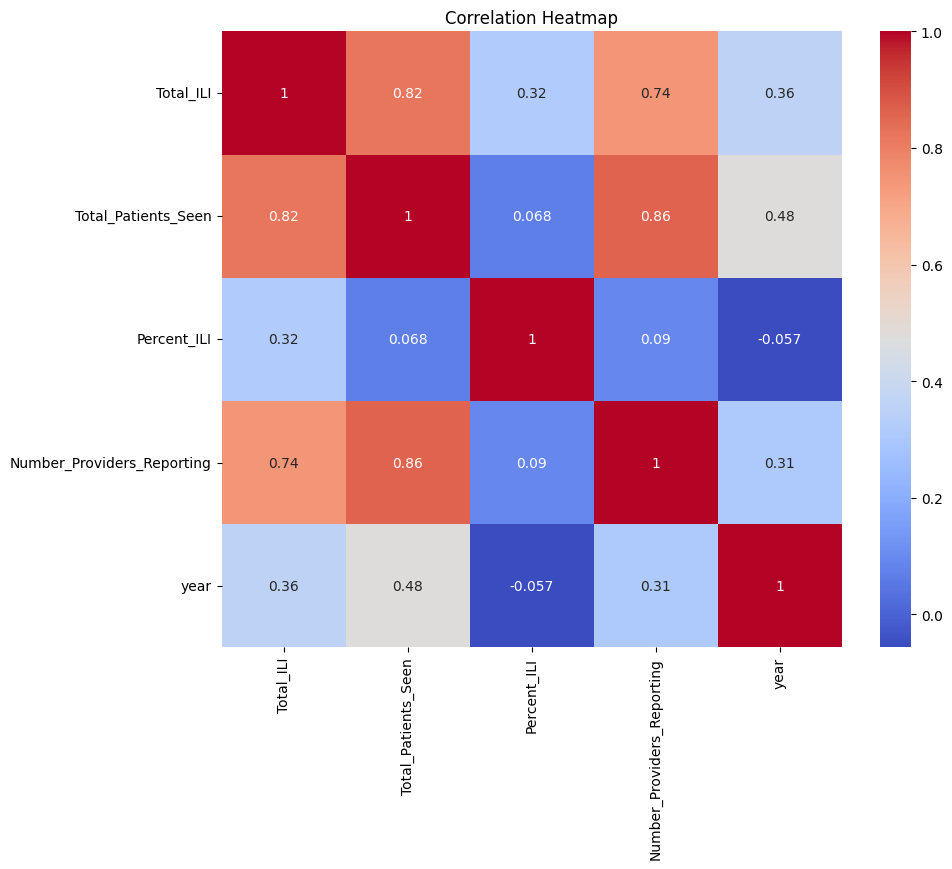

In [84]:
# 3. After preprocessing, we can now analyze the correlations between key features and Percent_ILI. We will select relevant features and compute the correlation matrix, then visualize it using a heatmap.
features = ['Total_ILI','Total_Patients_Seen', 'Percent_ILI','Number_Providers_Reporting','year']
corr = df[features].corr()

# Create a heatmap to visualize correlations 
# Annotations (annot=True) show the correlation coefficient values
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

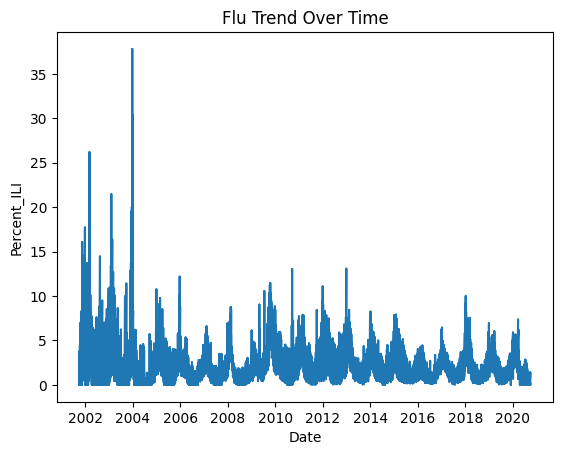

In [85]:
# We can visualize the trend of Percent_ILI over time to see how influenza-like illness has evolved across the weeks and years in the dataset.
plt.figure()
plt.plot(df['weekending'], df['Percent_ILI'])
plt.title("Flu Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Percent_ILI")
plt.show()

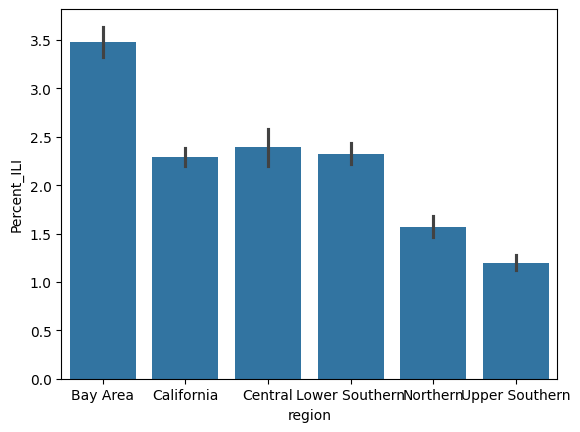

In [86]:
# We can also analyze the distribution of Percent_ILI across different regions to see if there are regional differences in influenza-like illness rates.
sns.barplot(data=df, x='region', y='Percent_ILI')
plt.show()

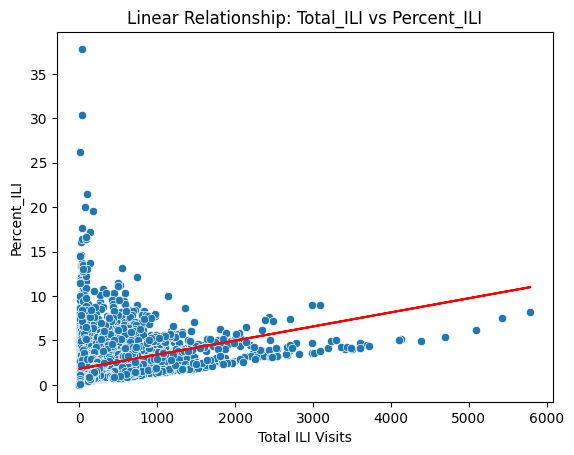

In [87]:
x = df['Total_ILI']
y = df['Percent_ILI']

# Fit line
m, b = np.polyfit(x, y, 1)
sns.scatterplot(x=x, y=y)
plt.plot(x, m*x + b, color='red')
plt.title("Linear Relationship: Total_ILI vs Percent_ILI")
plt.xlabel("Total ILI Visits")
plt.ylabel("Percent_ILI")
plt.show()

# <a id='toc5_'></a>[5. MODELING](#toc0_)

In [88]:
# 4. Define features (X) and target (y)
features = ['Total_ILI', 'Total_Patients_Seen', 
                 'Number_Providers_Reporting', 'region', 'year']

X = df[features]
y = df['Percent_ILI']

In [89]:
# For linear regression, we need to encode the categorical 'region' variable using one-hot encoding. This will create new binary columns for each region, allowing the linear regression model to interpret the categorical data.
# drop_first=True reduces multi-collinearity (avoids dummy variable trap)
X_lr = pd.get_dummies(X, columns=['region'], drop_first=True)

In [90]:
# For tree-based models, we can use one-hot encoding without dropping the first category, as tree-based models are not affected by multicollinearity in the same way linear regression is. 
# This allows us to retain all region categories for better model performance.

X_tree = pd.get_dummies(X, columns=['region'], drop_first=False)

## <a id='toc5_1_'></a>[5.1 TRAIN - TEST SPLIT](#toc0_)

In [91]:
# 5. Train - test split
# Linear Regression split
# Split data into training (80%) and testing (20%) sets
# random_state=42 ensures reproducibility of the split by providing a fixed set for the random number generator. 
X_train_lr, X_test_lr, y_train, y_test = train_test_split(
    X_lr, y, test_size=0.2, random_state=42
)

# Tree models split
# Split data into training (80%) and testing (20%) sets
# random_state=42 ensures reproducibility of the split by providing a fixed set for the random number generator. 
X_train_tree, X_test_tree, _, _ = train_test_split(
    X_tree, y, test_size=0.2, random_state=42
)

## <a id='toc5_2_'></a>[5.2 SCALING](#toc0_)

In [92]:
# 6. Scaling the features
# For linear regression, we need to standardize the features to ensure that they are on the same scale. 
# This is important because linear regression is sensitive to the scale of the features, and standardizing can improve model performance and convergence.
# Initialize the scaler object
scaler = StandardScaler()

# Fit to training data to learn mean/std, then transform it to standardize the training features.
X_train_lr_scaled = scaler.fit_transform(X_train_lr)

# Transform test data using the parameters learned ONLY from X_train to prevent data leakage. 
# This ensures that the test set is scaled in the same way as the training set without using any information from the test set during fitting.
X_test_lr_scaled = scaler.transform(X_test_lr)

# <a id='toc6_'></a>[6. MODELS](#toc0_)

## <a id='toc6_1_'></a>[6.1 LINEAR REGRESSION](#toc0_)

In [93]:
# 1. Linear Regression
# Initialize the model 
lr_model = LinearRegression()

# Train the model: Fit the estimator to the scaled training data to learn coefficients 
lr_model.fit(X_train_lr_scaled, y_train)

# Make predictions: Use the trained model to predict target values for the test set 
y_pred_lr = lr_model.predict(X_test_lr_scaled)

# Evaluate performance: Print key metrics to assess model accuracy
print("Linear Regression:")

# Mean Squared Error (MSE): Measures the average squared difference between actual and predicted values
# A value closer to 0 indicates better performance 
print("MSE:", mean_squared_error(y_test, y_pred_lr))

# R-squared (R2): Represents the proportion of variance explained by the model
# A score of 1.0 is a perfect fit 
print("R2:", r2_score(y_test, y_pred_lr))

Linear Regression:
MSE: 3.2686362317726108
R2: 0.31747491000134054


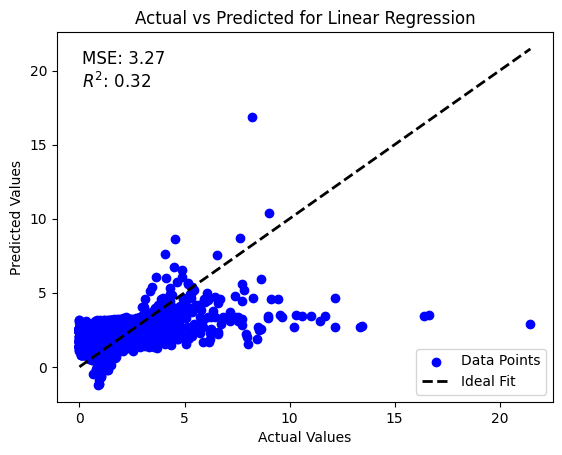

In [108]:
# Create scatter plot
# Calculate evaluation metrics (MSE and R2)
mse = mean_squared_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)

# Plot actual vs predicted data points
plt.scatter(y_test, y_pred_lr, color='blue', label='Data Points')

# Plot the ideal 1:1 fit line to show where perfect predictions would lie
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Ideal Fit')

# Add MSE and R^2 annotation to the plot for quick performance evaluation
plt.annotate(f'MSE: {mse:.2f}\n$R^2$: {r2:.2f}', # Text to display (rounded to 2 decimal places)
             xy=(0.05, 0.85), # Position (x, y) in axes coordinates
             xycoords='axes fraction',  # Use fraction of axes (0,0 to 1,1)
             fontsize=12)
# Configure plot labels, title, and legend
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted for Linear Regression')
plt.legend()
plt.show()

In [95]:
# View learned coefficients to understand the impact of each feature on the target variable. 
# This allows us to see which features have the most influence on the predicted Percent_ILI values, with positive coefficients indicating a direct relationship and negative coefficients indicating an inverse relationship.
coef_df = pd.DataFrame({'Feature': X_train_lr.columns, 'Coefficient': lr_model.coef_})
print(coef_df.sort_values('Coefficient', ascending=False))

                      Feature  Coefficient
0                   Total_ILI     1.519133
2  Number_Providers_Reporting     0.330140
3                        year    -0.178191
5              region_Central    -0.230387
6       region_Lower Southern    -0.297398
7             region_Northern    -0.514945
4           region_California    -0.572483
8       region_Upper Southern    -0.662461
1         Total_Patients_Seen    -1.204805


## <a id='toc6_2_'></a>[6.2 RANDOM FOREST](#toc0_)

In [96]:
# 2. Random Forest
# Initialize and train a Random Forest Regressor with 100 trees 
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_tree, y_train)

# Predict target values for the test set
y_pred_rf = rf_model.predict(X_test_tree)

# Evaluate model performance using Mean Squared Error and R-squared metrics
print("Random Forest:")
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R2:", r2_score(y_test, y_pred_rf))

Random Forest:
MSE: 0.13226019567226932
R2: 0.9723827016671411


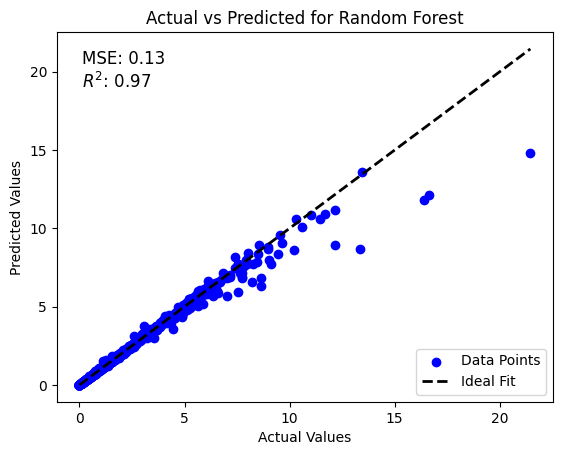

In [109]:
# Create scatter plot
mse = mean_squared_error(y_test, y_pred_rf)
r2 = r2_score(y_test, y_pred_rf)

# Plot actual vs predicted data points
plt.scatter(y_test, y_pred_rf, color='blue', label='Data Points')

# Plot the ideal 1:1 fit line to show where perfect predictions would lie
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Ideal Fit')

# Add MSE and R^2 to plot
plt.annotate(f'MSE: {mse:.2f}\n$R^2$: {r2:.2f}', # Text to display (rounded to 2 decimal places)
             xy=(0.05, 0.85), # Position (x, y) in axes coordinates
             xycoords='axes fraction', # Use fraction of axes (0,0 to 1,1)
             fontsize=12)

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted for Random Forest')
plt.legend()
plt.show()

In [98]:
# View learned coefficients to understand the impact of each feature on the target variable. 
# This allows us to see which features have the most influence on the predicted Percent_ILI values, with positive coefficients indicating a direct relationship and negative coefficients indicating an inverse relationship.
coef_df = pd.DataFrame({'Feature': X_train_lr.columns, 'Coefficient': lr_model.coef_})
print(coef_df.sort_values('Coefficient', ascending=False))

                      Feature  Coefficient
0                   Total_ILI     1.519133
2  Number_Providers_Reporting     0.330140
3                        year    -0.178191
5              region_Central    -0.230387
6       region_Lower Southern    -0.297398
7             region_Northern    -0.514945
4           region_California    -0.572483
8       region_Upper Southern    -0.662461
1         Total_Patients_Seen    -1.204805


## <a id='toc6_3_'></a>[6.3 XGBOOST](#toc0_)

### <a id='toc6_3_1_'></a>[6.3.1 XGBOOST LEARNING CURVE](#toc0_)

In [99]:
# 1. Initialize the XGBoost Regressor with specified hyperparameters
# n_estimators: Number of boosting rounds (trees) to build.
# random_state: Ensures reproducibility of results.
# eval_metric: Metric used to evaluate model performance (Root Mean Squared Error).
xgb_model = XGBRegressor(n_estimators=100, random_state=42, eval_metric='rmse')

# 2. Train (fit) the model
# eval_set: Monitors performance on both training and testing sets during training.
xgb_model.fit(X_train_tree, y_train, eval_set=[(X_train_tree, y_train), (X_test_tree, y_test)])

# Make predictions on unseen test data
y_pred_xgb = xgb_model.predict(X_test_tree) 

print('XGBoost:')

# Calculate and print Mean Squared Error (lower is better). 
print('MSE:', mean_squared_error(y_test, y_pred_xgb)) 

# Calculate and print R-squared score (higher is better).
print('R2:', r2_score(y_test, y_pred_xgb))

[0]	validation_0-rmse:1.66637	validation_1-rmse:1.70750


[1]	validation_0-rmse:1.29667	validation_1-rmse:1.36162
[2]	validation_0-rmse:1.02076	validation_1-rmse:1.08543
[3]	validation_0-rmse:0.81778	validation_1-rmse:0.88784
[4]	validation_0-rmse:0.65604	validation_1-rmse:0.74249
[5]	validation_0-rmse:0.53060	validation_1-rmse:0.63105
[6]	validation_0-rmse:0.43749	validation_1-rmse:0.54991
[7]	validation_0-rmse:0.36803	validation_1-rmse:0.48690
[8]	validation_0-rmse:0.31661	validation_1-rmse:0.44168
[9]	validation_0-rmse:0.28301	validation_1-rmse:0.40503
[10]	validation_0-rmse:0.25289	validation_1-rmse:0.37749
[11]	validation_0-rmse:0.22540	validation_1-rmse:0.36001
[12]	validation_0-rmse:0.21004	validation_1-rmse:0.34776
[13]	validation_0-rmse:0.19547	validation_1-rmse:0.32602
[14]	validation_0-rmse:0.19076	validation_1-rmse:0.31997
[15]	validation_0-rmse:0.18173	validation_1-rmse:0.31528
[16]	validation_0-rmse:0.17581	validation_1-rmse:0.31148
[17]	validation_0-rmse:0.17311	validation_1-rmse:0.30815
[18]	validation_0-rmse:0.16840	validatio

In [100]:
# Extract evaluation results to analyze the learning curve of the XGBoost model during training. 
# This will allow us to visualize how the model's performance evolved over the boosting rounds.
results = xgb_model.evals_result()

# Extract the RMSE values for both training and validation sets from the evaluation results.
train_rmse = results['validation_0']['rmse']

# Extract the RMSE values for the validation set to analyze how the model's performance on unseen data evolved during training.
test_rmse = results['validation_1']['rmse']

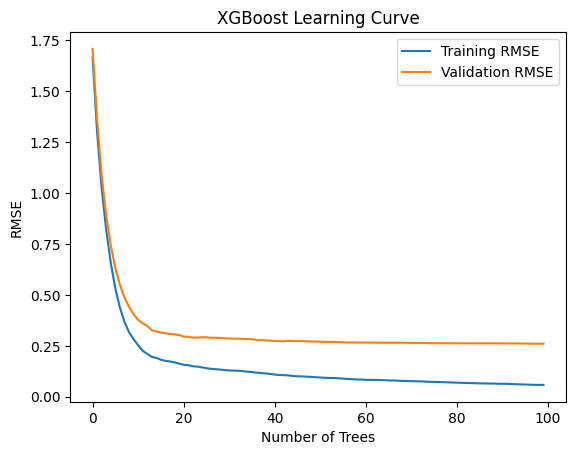

In [101]:
plt.figure()

# Plot training error (RMSE) against the number of boosting iterations (trees) 
plt.plot(train_rmse, label='Training RMSE')

# Plot validation error (RMSE) to monitor for overfitting
plt.plot(test_rmse, label='Validation RMSE')

plt.xlabel('Number of Trees') # The x-axis represents the number of boosting rounds
plt.ylabel('RMSE') # The y-axis represents the Root Mean Square Error
plt.title('XGBoost Learning Curve')
plt.legend()
plt.show()

### <a id='toc6_3_2_'></a>[6.3.2 XGBOOST MODEL](#toc0_)

In [102]:
# 3. XGBoost
# Initialize the XGBoost Regressor with specified hyperparameters
# n_estimators: Number of boosting rounds (trees)
# random_state: Ensures reproducibility of results (same sequence of random numbers for consistent results across runs)
xgb_model = XGBRegressor(n_estimators=50, random_state=42)

# Train the model using the training dataset 
xgb_model.fit(X_train_tree, y_train)

# Predict target values for the test set 
y_pred_xgb = xgb_model.predict(X_test_tree)

# Evaluate the model performance 
print("XGBoost:")
print("MSE:", mean_squared_error(y_test, y_pred_xgb))
print("R2:", r2_score(y_test, y_pred_xgb))

XGBoost:
MSE: 0.07319379417649424
R2: 0.984716377897285


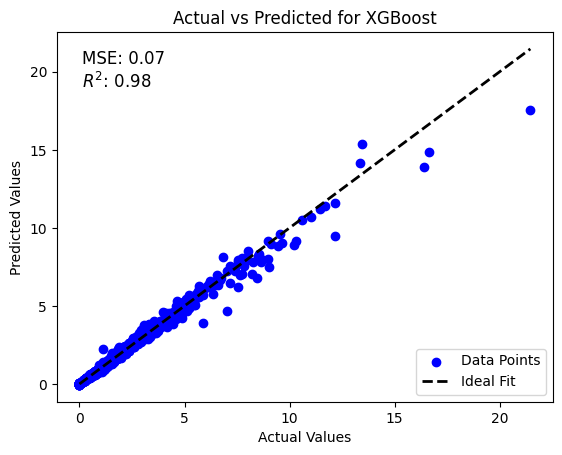

In [110]:
# Create scatter plot
mse = mean_squared_error(y_test, y_pred_xgb)
r2 = r2_score(y_test, y_pred_xgb)

# Plot actual vs predicted data points
plt.scatter(y_test, y_pred_xgb, color='blue', label='Data Points')

# Plot the ideal 1:1 fit line to show where perfect predictions would lie
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Ideal Fit')

# Add MSE and R^2 to plot
plt.annotate(f'MSE: {mse:.2f}\n$R^2$: {r2:.2f}', # Text to display (rounded to 2 decimal places)
             xy=(0.05, 0.85),  # Position (x, y) in axes coordinates
             xycoords='axes fraction', # Use fraction of axes (0,0 to 1,1)
             fontsize=12)

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted for XGBoost')
plt.legend()
plt.show()

# <a id='toc7_'></a>[7. FEATURE IMPORTANCE GRAPHS](#toc0_)

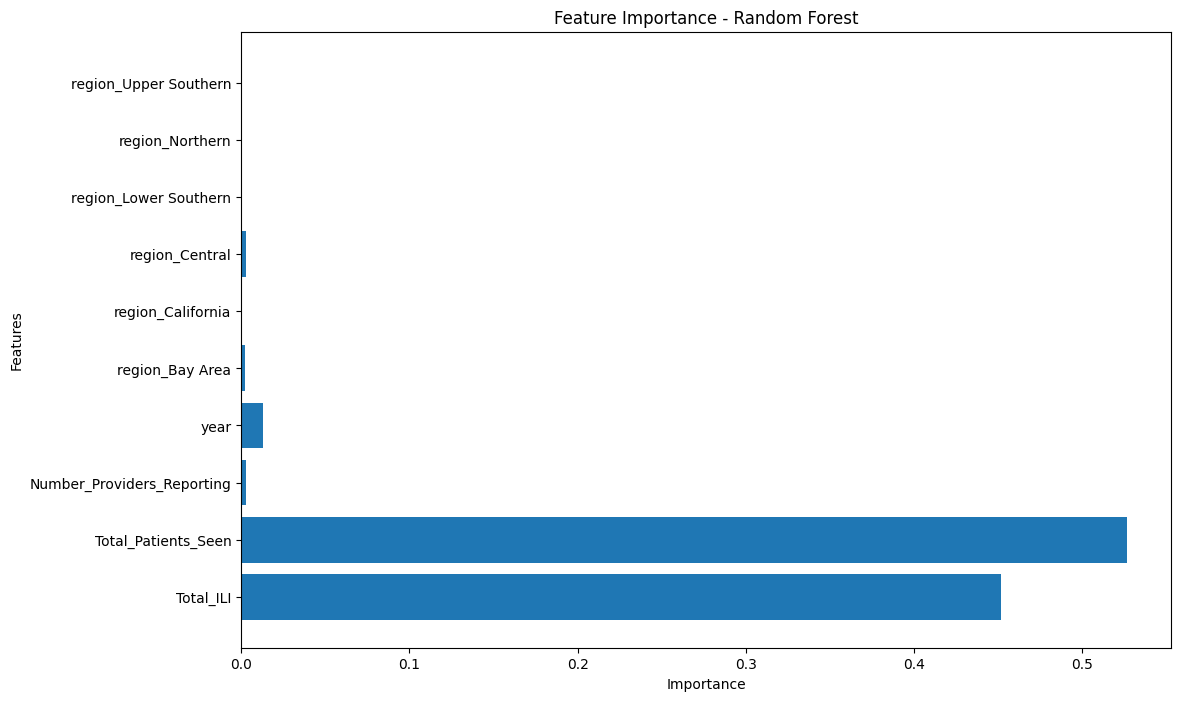

In [111]:
# 1. Feature importance from Random Forest.
# Higher values indicate more important features for predicting percent_ILI 
importances = rf_model.feature_importances_ 

# Plot
plt.figure(figsize=(12, 8))  # bigger figure
plt.barh(X_tree.columns, importances) # Use X_tree.columns to provide the labels for the y-axis. 
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

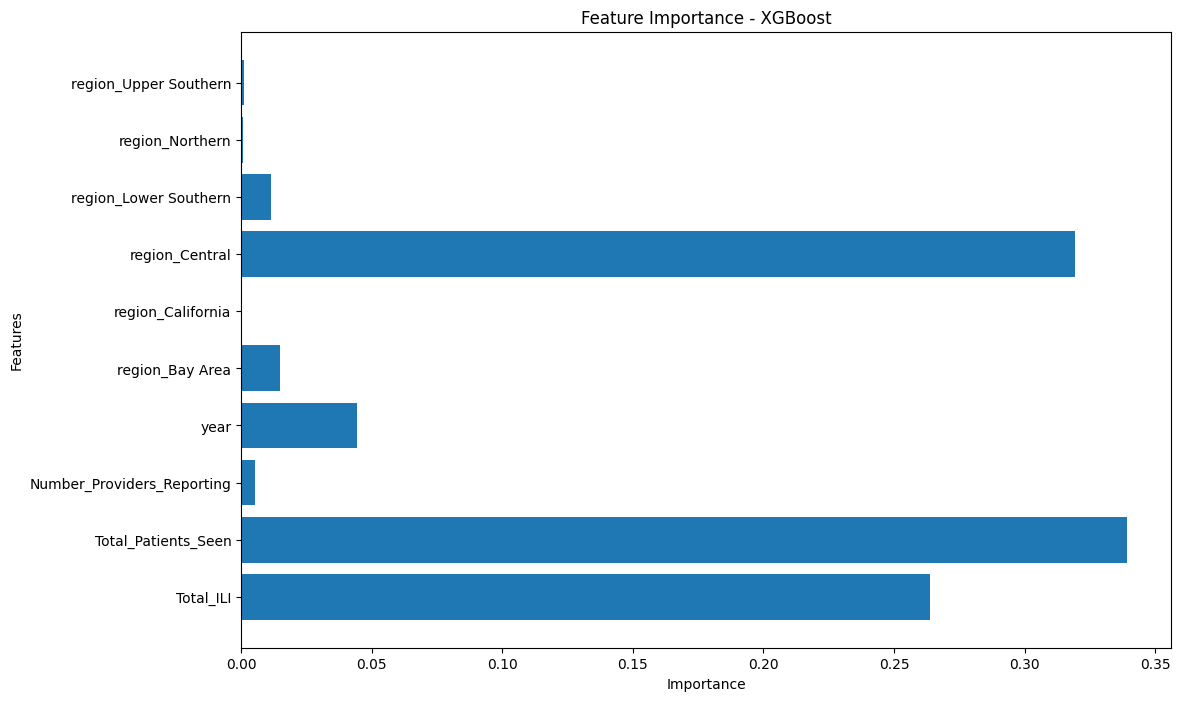

In [112]:
# 2. Feature importance from XGBoost.
# Higher values indicate more important features for predicting percent_ILI 
importances = xgb_model.feature_importances_ 

plt.figure(figsize=(12, 8))  # bigger figure
plt.barh(X_tree.columns, importances) # Use X_tree.columns to provide the labels for the y-axis. 
plt.title("Feature Importance - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

# <a id='toc8_'></a>[8. MODEL COMPARISON GRAPH](#toc0_)

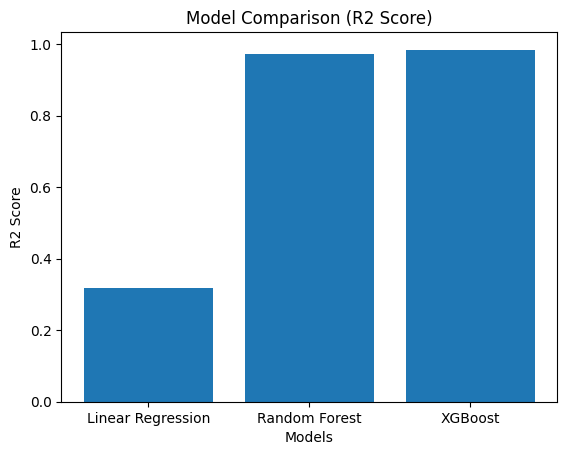

In [106]:
# Define models and their corresponding R2 scores
# We create a list of model names and a list of their corresponding R2 scores to facilitate the comparison of model performance. This allows us to easily visualize which model performs best in terms of explaining the variance in the target variable (Percent_ILI).
models = ['Linear Regression', 'Random Forest', 'XGBoost']
r2_scores = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_rf),
    r2_score(y_test, y_pred_xgb)
]

# Create the bar plot to visually compare the accuracy of the three models. Each bar represents a model, and its height corresponds to the accuracy score.
plt.figure()
plt.bar(models, r2_scores)
plt.title("Model Comparison (R2 Score)")
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.show()

# <a id='toc9_'></a>[9. K-FOLD CROSS VALIDATION](#toc0_)

In [107]:
# Set up the K-Fold cross-validation strategy.
# - n_splits=5: Data is split into 5 subsets (folds). The model trains on 4 and tests on 1, repeating 5 times.
# - shuffle=True: The data is shuffled before splitting, ensuring no bias from original data ordering.
# - random_state=42: Ensures reproducibility. Using the same integer ensures the same splits every time the code runs.
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate Linear Regression (linreg) using the encoded features for linear regression
lr_scores = cross_val_score(lr_model, X_lr, y, cv=kf, scoring='r2')
print("Linear Regression CV R2:", lr_scores.mean())

# Evaluate Random Forest (rf) using the encoded features for tree-based models
rf_scores = cross_val_score(rf_model, X_tree, y, cv=kf, scoring='r2')
print("Random Forest CV R2:", rf_scores.mean())

# Evaluate XGBoost (xgb) using the encoded features for tree-based models
xgb_scores = cross_val_score(xgb_model, X_tree, y, cv=kf, scoring='r2')
print("XGBoost CV R2:", xgb_scores.mean())

Linear Regression CV R2: 0.2874865729856131
Random Forest CV R2: 0.9571610627353028
XGBoost CV R2: 0.9550821483475417
